In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Gettiing Webpage

url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [5]:
#Parsing HTML

soup = BeautifulSoup(
    response.text,
    'html.parser'
)

In [6]:
#Finding Books

books = soup.find_all('article', class_='product_pod')

print("Number of books found:", len(books))

Number of books found: 20


In [7]:
#Extrating Information

data = []

for book in books:
    
    title = book.h3.a['title']
    
    price = book.find(
        'p',
        class_='price_color'
    ).text.strip()
    
    rating = book.find(
        'p',
        class_='star-rating'
    )['class'][1]
    
    availability = book.find(
        'p',
        class_='instock availability'
    ).text.strip()
    
    data.append({
        'Title': title,
        'Price': price,
        'Rating': rating,
        'Availability': availability
    })

books_df = pd.DataFrame(data)

books_df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [9]:
#Cleaning Price

books_df['Price'] = (
    books_df['Price']
    .str.replace(r'[^\d.]', '', regex=True)
    .astype(float)
)

In [11]:
#Coverting ratings to numbers

rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

books_df['Rating_Value'] = books_df['Rating'].map(
    rating_map
)

In [12]:
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         20 non-null     str    
 1   Price         20 non-null     float64
 2   Rating        20 non-null     str    
 3   Availability  20 non-null     str    
 4   Rating_Value  20 non-null     int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 1.8 KB


In [13]:
books_df.describe()

,Price,Rating_Value
count,20.000000,20.000000
mean,38.048500,2.850000
std,15.135231,1.565248
min,13.990000,1.000000
25%,22.637500,1.000000
50%,41.380000,3.000000
75%,51.865000,4.000000
max,57.250000,5.000000


In [14]:
#Most expensive Books

books_df.sort_values(
    'Price',
    ascending=False
).head(10)

,Title,Price,Rating,Availability,Rating_Value
15,Our Band Could Be Your Life: Scenes from the A...,57.25,Three,In stock,3
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,5
1,Tipping the Velvet,53.74,One,In stock,1
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,Five,In stock,5
9,The Black Maria,52.15,One,In stock,1
0,A Light in the Attic,51.77,Three,In stock,3
18,Libertarianism for Beginners,51.33,Two,In stock,2
2,Soumission,50.10,One,In stock,1
3,Sharp Objects,47.82,Four,In stock,4
19,It's Only the Himalayas,45.17,Two,In stock,2


In [15]:
#Highest Rated Books

books_df.sort_values(
    'Rating_Value',
    ascending=False
).head(10)

,Title,Price,Rating,Availability,Rating_Value
12,Set Me Free,17.46,Five,In stock,5
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,Five,In stock,5
14,Rip it Up and Start Again,35.02,Five,In stock,5
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,5
11,Shakespeare's Sonnets,20.66,Four,In stock,4
6,The Dirty Little Secrets of Getting Your Dream...,33.34,Four,In stock,4
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four,In stock,4
3,Sharp Objects,47.82,Four,In stock,4
15,Our Band Could Be Your Life: Scenes from the A...,57.25,Three,In stock,3
7,The Coming Woman: A Novel Based on the Life of...,17.93,Three,In stock,3


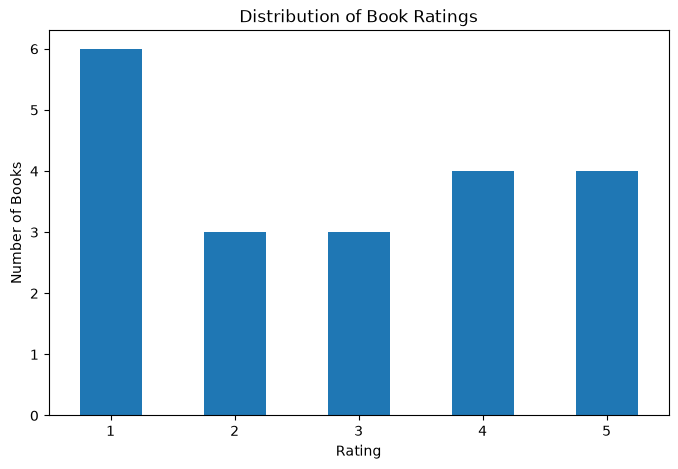

In [16]:
#Rating Distribution

rating_counts = books_df['Rating_Value'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

rating_counts.plot(kind='bar')

plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Books')
plt.xticks(rotation=0)

plt.show()

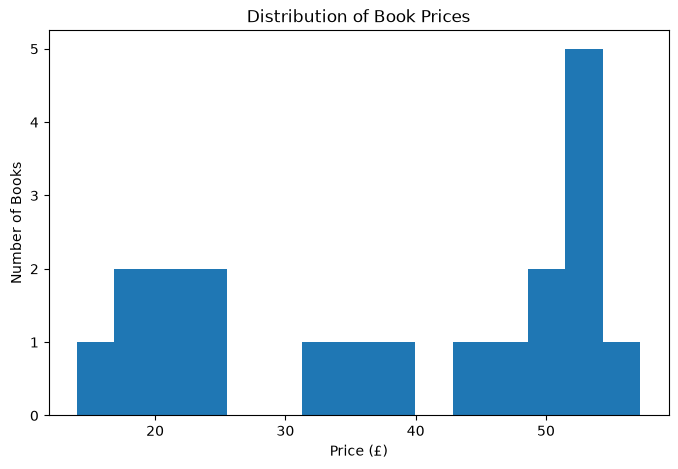

In [17]:
#Price Distribution

plt.figure(figsize=(8, 5))

plt.hist(
    books_df['Price'],
    bins=15
)

plt.title('Distribution of Book Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')

plt.show()

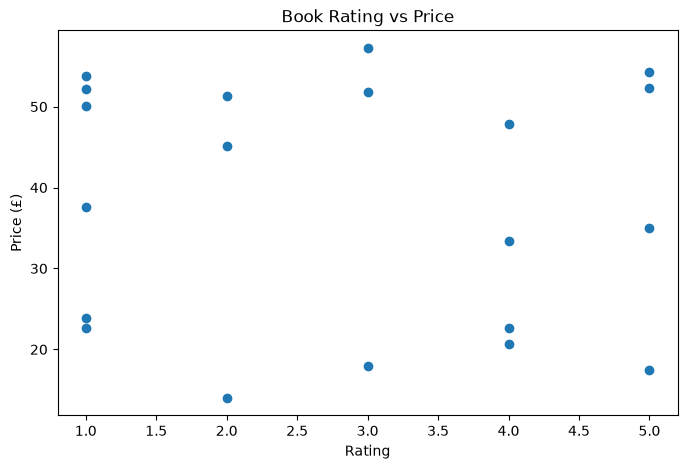

In [18]:
#Rating vs Price

plt.figure(figsize=(8, 5))

plt.scatter(
    books_df['Rating_Value'],
    books_df['Price']
)

plt.title('Book Rating vs Price')
plt.xlabel('Rating')
plt.ylabel('Price (£)')

plt.show()

In [19]:
#Saving Scraped Data

books_df.to_csv(
    'scraped_books_data.csv',
    index=False
)

## Task 5 Conclusion

Publicly available book data was collected using Python, Requests and BeautifulSoup. The extracted information was structured into a Pandas DataFrame and cleaned for analysis. Price and rating distributions were analyzed using descriptive statistics and visualizations. The final scraped dataset was exported as a CSV file.